(100,)


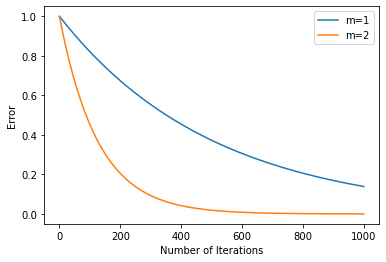

In [29]:
# Import libraries
import numpy as np
import matplotlib
from matplotlib  import pyplot as plt
import time
from numba import njit

M = 100
alpha = 2.00000001
itermax = 1000

@njit
def get_b(m):
    b = np.zeros((M,1))
    eigenval = alpha - 2*np.cos(2*np.pi*m/M)
    for n in range(0,M):
        v_mn = np.sin(-2*np.pi*m*n/M)
        #v_mn = complex(np.cos(-2*np.pi*m*n/M), np.sin(-2*np.pi*m*n/M))
        b[n] = eigenval * v_mn
    return b

@njit
def get_T():
    T = np.zeros((M,M))
    
    T[0,0] = alpha
    T[0,1] = -1
    T[0,-1] = -1
    
    T[-1,0] = -1
    T[-1,-2] = -1
    T[-1,-1] = alpha
    
    for i in range(1,M-1):
        T[i,i] = alpha
        T[i,i-1] = -1
        T[i,i+1] = -1

    return T

def jacobi_cyclic(xold,alpha,b):
    xnew = np.zeros(xold.shape)
    xnew[1:-1] = 1/alpha * (b[1:-1] + xold[2:] + xold[:-2])
    xnew[0] = 1/alpha * (b[0] + xold[1] + xold[-1])
    xnew[-1] = 1/alpha * (b[-1] + xold[0] + xold[-2])
    return xnew

errs1 = np.zeros((itermax,1))
errs2 = np.zeros((itermax,1))

b1 = get_b(1).flatten()
b2 = get_b(2).flatten()
T = get_T()

print(b2.shape)

x1_exact = np.linalg.solve(T,b1)
x2_exact = np.linalg.solve(T,b2)

errs1[0] = np.max(abs(x1_exact))
errs2[0] = np.max(abs(x2_exact))


# Solve for v1
iter_num = 1
xold = np.zeros(b1.shape)

while (iter_num < itermax):
    xnew = jacobi_cyclic(xold, 2.0, b1)
    errs1[iter_num] = np.max(abs(x1_exact - xnew))
    xold = xnew
    
    iter_num += 1
    

# Solve for v2
iter_num = 1
xold = np.zeros(b1.shape)

while (iter_num < itermax):
    xnew = jacobi_cyclic(xold, 2.0, b2)
    errs2[iter_num] = np.max(abs(x2_exact - xnew))
    xold = xnew
    
    iter_num += 1
    

plt.figure()
plt.plot(errs1, label='m=1')
plt.plot(errs2, label='m=2')
plt.legend()
plt.xlabel('Number of Iterations')
plt.ylabel('Error')

# Check if iterative method matches dense solve
#plt.figure()
#plt.plot(xnew, label='Iterative')
#plt.plot(x2_exact, label='Solve')
#plt.legend()

plt.show()

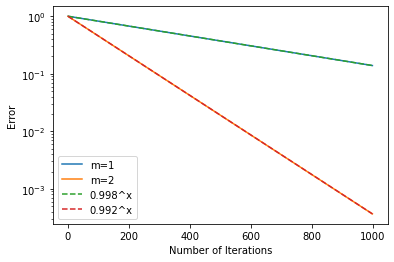

In [33]:
from scipy.optimize import curve_fit

def model(x, A, B):
    return A * B**x

x = np.arange(0,itermax,1)

params_v1, _ = curve_fit(model, x, errs1.ravel())
A1, B1 = params_v1

params_v2, _ = curve_fit(model, x, errs2.ravel())
A2, B2 = params_v2

plt.figure()
plt.semilogy(errs1, label='m=1')
plt.semilogy(errs2, label='m=2')
plt.semilogy(A1*B1**x, '--', label=f'{np.round(B1,3)}^x')
plt.semilogy(A2*B2**x, '--', label=f'{np.round(B2,3)}^x')
plt.legend()
plt.xlabel('Number of Iterations')
plt.ylabel('Error')

plt.show()